**3D Acoustic Wavefield Simulation Using U-Net Enhanced Fourier Neural Operator**

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
cd "/content/gdrive/My Drive/UU/PhD_project/Wavefield_Simulation/"

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_5743/3209448586.py", line 1, in <cell line: 0>
    get_ipython().run_line_magic('cd', '"/content/gdrive/My Drive/UU/PhD_project/Wavefield_Simulation/"')
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2418, in run_line_magic
    result = fn(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^
  File "<decorator-gen-85>", line 2, in cd
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/magic.py", line 187, in <lambda>
    call = lambda f, *a, **k: f(*a, **k)
                              ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/magics/osm.py", line 342, in cd
    oldcwd = os.getcwd()
             ^^^^^^^^^^^
OSError: [Errno 107] Transport endpoint is not connected

During handling of the above ex

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from plotting import plot3d
import random

In [4]:
def read_models(data_root, model_folders, index):
    """Read a binary float32 velocity model (96x96x96)."""
    vp_file = os.path.join(data_root, model_folders[index], "vp3d.bin")
    shape = (96, 96, 96)          # Make sure NX, NY, NZ are defined globally
    vp = np.memmap(vp_file, dtype=np.float32, mode='r', shape=shape)
    return np.array(vp)


def generate_sources(n_train, n_test, nx, ny, nz, pml_width, seed=42):

    margin = pml_width + 5
    rng = np.random.default_rng(seed)
    lo = margin
    hi = [nx - margin, ny - margin, nz - margin]

    n_total = n_train + n_test
    all_locs = rng.integers(low=lo, high=hi, size=(n_total, 3), dtype=np.int32)

    train_locs = all_locs[:n_train]
    test_locs  = all_locs[n_train:]

    return train_locs, test_locs


def plot_source_distribution(vel, train_srcs, test_srcs, save_path=None):
    """
    Visualize training and test source locations
    inside the 3D velocity model.

    Green circles : training sources
    Red stars     : test sources
    """
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    # transparent velocity slices
    nx, ny, nz = vel.shape
    # training sources
    train_srcs = np.array(train_srcs)
    ax.scatter(train_srcs[:, 0], train_srcs[:, 1], train_srcs[:, 2], c='lime', s=120, marker='o', edgecolors='black', linewidths=1.0, depthshade=False, label='Training Sources')
    # test sources
    test_srcs = np.array(test_srcs)
    ax.scatter(test_srcs[:, 0], test_srcs[:, 1], test_srcs[:, 2], c='red', s=300, marker='*', edgecolors='black', linewidths=1.2, depthshade=False, label='Test Sources')
    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_zlim(0, nz)
    ax.set_xlabel("X", fontsize=12)
    ax.set_ylabel("Y", fontsize=12)
    ax.set_zlabel("Z", fontsize=12)
    ax.set_title("Sources Distribution", fontsize=12, pad=20)
    ax.legend(loc='upper right', fontsize=12)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
## Load data

# vel model
data_root = './'
model_folders = [f'model_{i:04d}' for i in range(100, 200)]
model_index = 2
seed = 202605

# Load snapshot data
label_shot = np.load('./results/ufno_true_snapshots_selected.npy', mmap_mode='r')
pred_shot = np.load('./results/ufno_pred_snapshots_selected.npy', mmap_mode='r')
error_shot = label_shot - pred_shot   # Compute error (difference)

shot_num = 1
time_slice_1 = 5
time_slice_2 = 11

# Load velocity model
vp_np = read_models(data_root, model_folders, model_index)

print(f"Velocity range: {vp_np.min():.1f} – {vp_np.max():.1f} m/s")
print("Label shape:", label_shot.shape)
print("Pred shape: ", pred_shot.shape)


Velocity range: 1834.0 – 4325.9 m/s
Label shape: (2, 20, 96, 96, 96)
Pred shape:  (2, 20, 96, 96, 96)


In [6]:
## generate random sources


n_train = 30
n_test = 5
nx, ny, nz = 96, 96, 96
pml_width = 0

train_sources, test_sources = generate_sources(n_train, n_test, nx, ny, nz, pml_width)

print(f"num of training sources: {len(train_sources)}")
print(f"num of testing sources: {len(test_sources)}")
print(f"the first 3 training sources:\n{train_sources[:3]}")

num of training sources: 30
num of testing sources: 5
the first 3 training sources:
[[12 71 61]
 [42 42 78]
 [12 64 22]]


OSError: [Errno 107] Transport endpoint is not connected: './results/ufno_results_comparison.png'

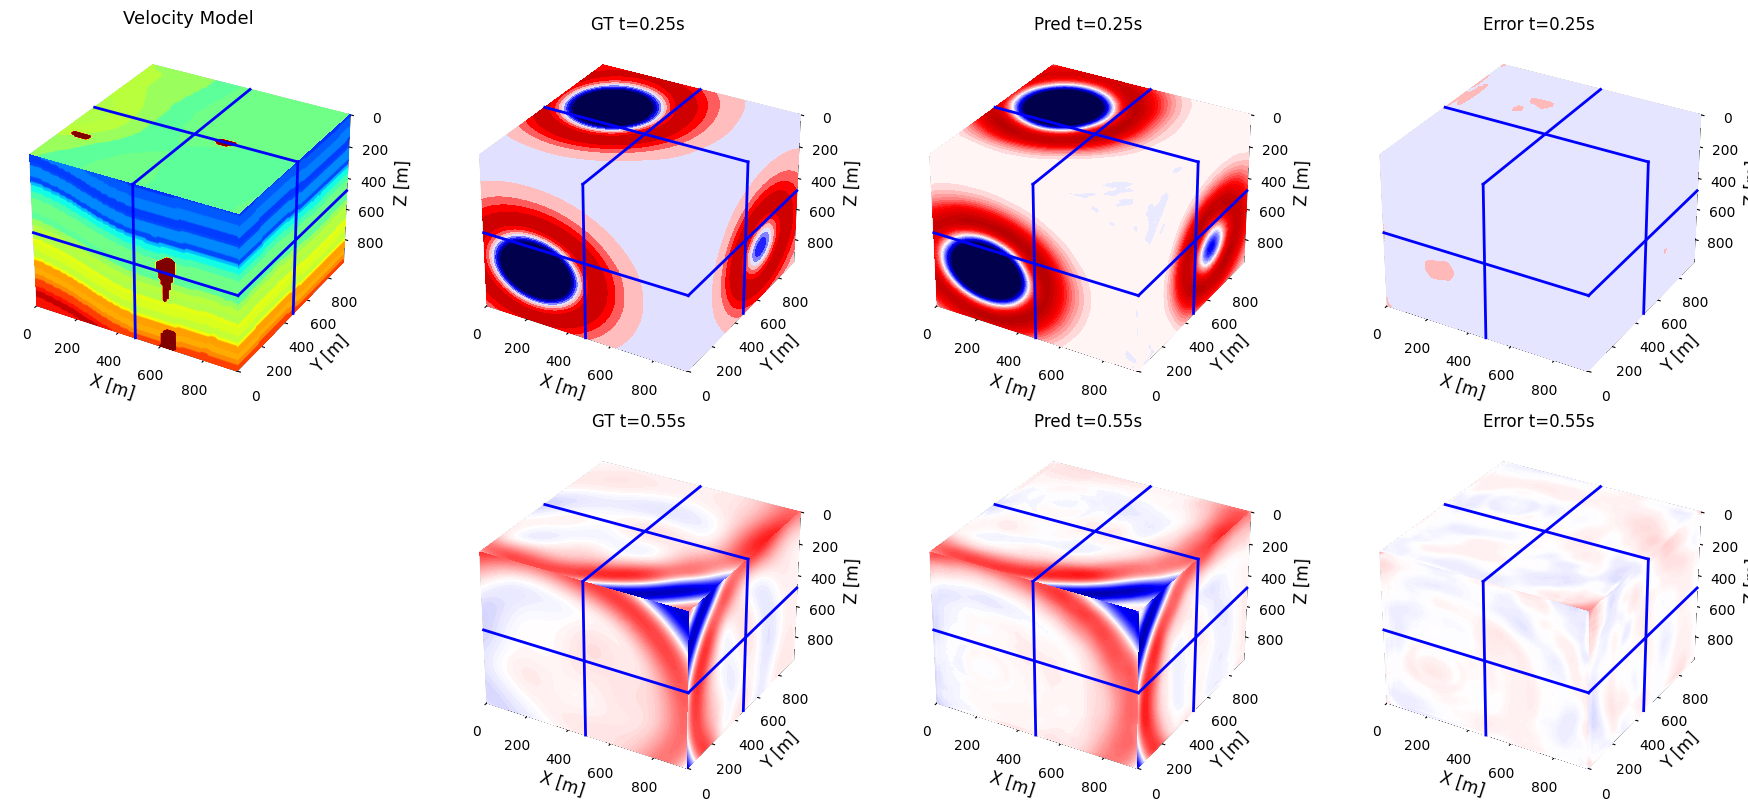

In [12]:
## Plot Figure

fig, ax = plt.subplots(2, 4, figsize=(18, 8),
                       subplot_kw={"projection": "3d"},
                       constrained_layout=True)

# Common parameters for wavefield plots (pressure/velocity snapshots)
plot_kwargs = {
    "cmap": "seismic",
    "vmin": -0.15,
    "vmax": 0.15,
    "dx": 10.0,
    "dy": 10.0,
    "dz": 10.0,
    "ifnewfig": False,
    "ifinside": False,
    "showf": False,
    "close": False,
}


# [0,0] Velocity Model
plt.sca(ax[0, 0])
plot3d(vp_np.T,
       cmap="jet",
       vmin=1500,
       vmax=3500,
       dx=10.0, dy=10.0, dz=10.0,
       ifnewfig=False, ifinside=False, showf=False, close=False)

ax[0, 0].set_title("Velocity Model", fontsize=13, pad=10)
ax[0, 0].set_xlabel('X [m]')
ax[0, 0].set_ylabel('Y [m]')
ax[0, 0].set_zlabel('Z [m]')

# [0,1] Ground Truth at time 1
plt.sca(ax[0, 1])
plot3d(label_shot[shot_num, time_slice_1, :, :, :], **plot_kwargs)
ax[0, 1].set_title(f"GT t={time_slice_1*0.05:.2f}s")

# [0,2] Prediction at time 1
plt.sca(ax[0, 2])
plot3d(pred_shot[shot_num, time_slice_1, :, :, :], **plot_kwargs)
ax[0, 2].set_title(f"Pred t={time_slice_1*0.05:.2f}s")

# [0,3] Error at time 1
plt.sca(ax[0, 3])
plot3d(error_shot[shot_num, time_slice_1, :, :, :], **plot_kwargs)
ax[0, 3].set_title(f"Error t={time_slice_1*0.05:.2f}s")




# [1,0] Empty (left blank intentionally)
ax[1, 0].axis('off')

# [1,1] Ground Truth at time 2
plt.sca(ax[1, 1])
plot3d(label_shot[shot_num, time_slice_2, :, :, :], **plot_kwargs)
ax[1, 1].set_title(f"GT t={time_slice_2*0.05:.2f}s")

# [1,2] Prediction at time 2
plt.sca(ax[1, 2])
plot3d(pred_shot[shot_num, time_slice_2, :, :, :], **plot_kwargs)
ax[1, 2].set_title(f"Pred t={time_slice_2*0.05:.2f}s")


plt.sca(ax[1, 3])
plot3d(error_shot[shot_num, time_slice_2, :, :, :], **plot_kwargs)
ax[1, 3].set_title(f"Error t={time_slice_2*0.05:.2f}s")



for i in range(2):
    for j in range(4):
        if not (i == 1 and j == 0):   # Skip the empty subplot
            ax[i, j].set_xlabel('X [m]')
            ax[i, j].set_ylabel('Y [m]')
            ax[i, j].set_zlabel('Z [m]')

plt.savefig('./results/ufno_results_comparison.png', dpi=300, bbox_inches='tight')
# plt.savefig('./results/ufno_results_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()


OSError: [Errno 107] Transport endpoint is not connected: './results/figures/ufno_results_comparison_new.png'

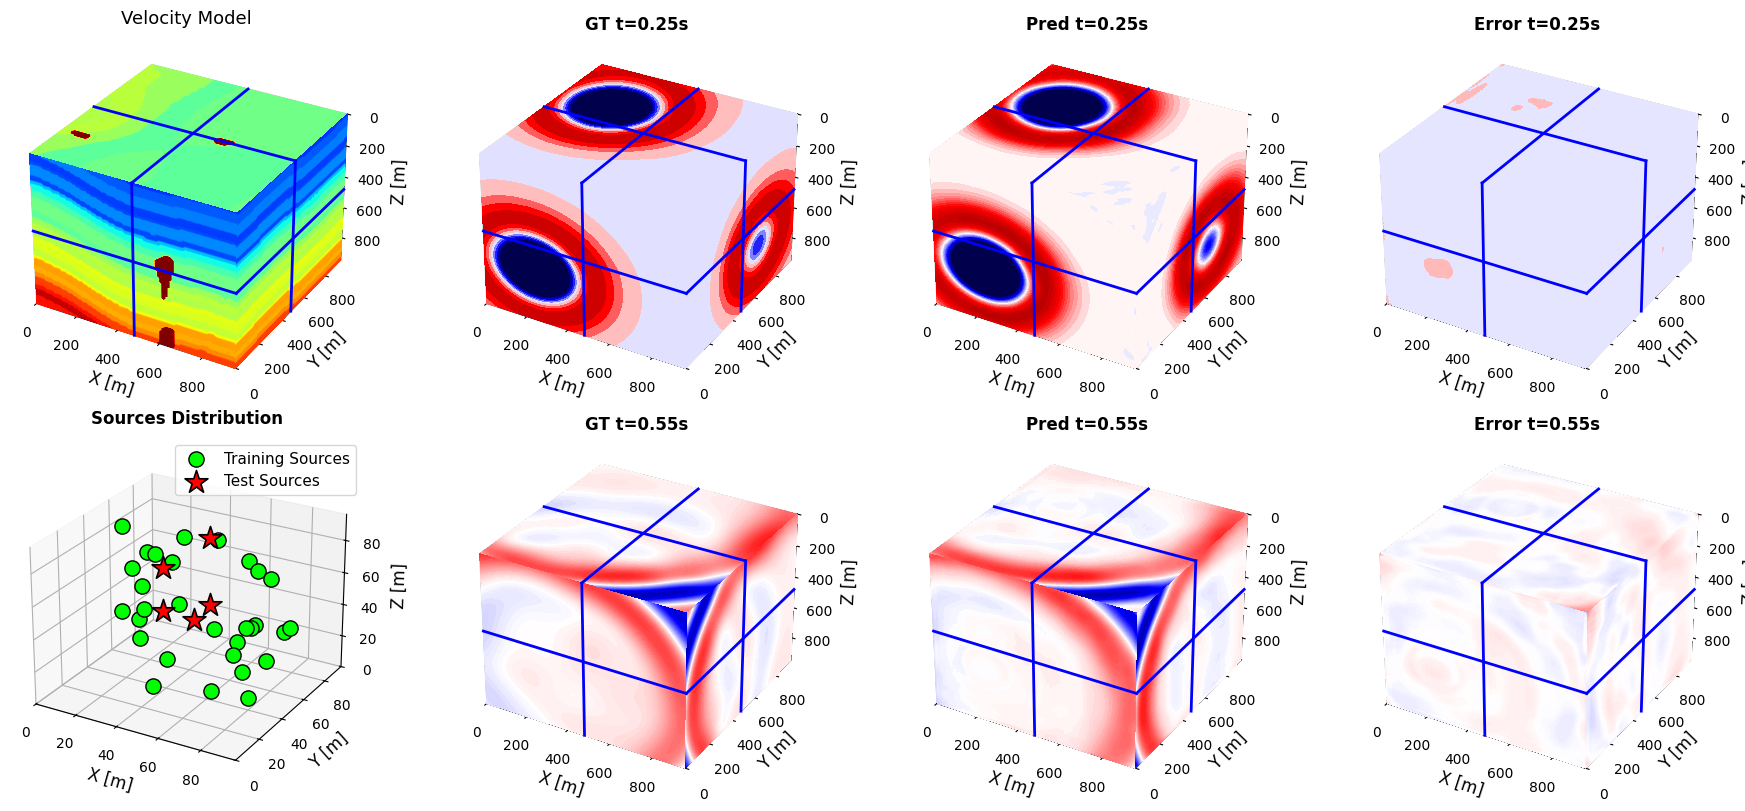

In [10]:
fig, ax = plt.subplots(2, 4, figsize=(18, 8),
                       subplot_kw={"projection": "3d"},
                       constrained_layout=True)

# Common parameters for wavefield plots
plot_kwargs = {
    "cmap": "seismic",
    "vmin": -0.15,
    "vmax": 0.15,
    "dx": 10.0,
    "dy": 10.0,
    "dz": 10.0,
    "ifnewfig": False,
    "ifinside": False,
    "showf": False,
    "close": False,
}

# [0,0] Velocity Model
plt.sca(ax[0, 0])
plot3d(vp_np.T,
       cmap="jet",
       vmin=1500,
       vmax=3500,
       dx=10.0, dy=10.0, dz=10.0,
       ifnewfig=False, ifinside=False, showf=False, close=False)

ax[0, 0].set_title("Velocity Model", fontsize=13, pad=10)
ax[0, 0].set_xlabel('X [m]')
ax[0, 0].set_ylabel('Y [m]')
ax[0, 0].set_zlabel('Z [m]')

# [0,1] Ground Truth at time 1
plt.sca(ax[0, 1])
plot3d(label_shot[shot_num, time_slice_1, :, :, :], **plot_kwargs)
ax[0, 1].set_title(f"GT t={time_slice_1*0.05:.2f}s", fontweight='bold')

# [0,2] Prediction at time 1
plt.sca(ax[0, 2])
plot3d(pred_shot[shot_num, time_slice_1, :, :, :], **plot_kwargs)
ax[0, 2].set_title(f"Pred t={time_slice_1*0.05:.2f}s", fontweight='bold')

# [0,3] Error at time 1
plt.sca(ax[0, 3])
plot3d(error_shot[shot_num, time_slice_1, :, :, :], **plot_kwargs)
ax[0, 3].set_title(f"Error t={time_slice_1*0.05:.2f}s", fontweight='bold')

# ====================== SOURCE DISTRIBUTION IN [1,0] ======================
plt.sca(ax[1, 0])

# Call the plotting logic directly on the existing axis
def plot_source_distribution_on_ax(ax, vel, train_srcs, test_srcs):
    nx, ny, nz = vel.shape
    train_srcs = np.array(train_srcs)
    test_srcs = np.array(test_srcs)

    # Training sources
    ax.scatter(train_srcs[:, 0], train_srcs[:, 1], train_srcs[:, 2],
               c='lime', s=120, marker='o', edgecolors='black',
               linewidths=1.0, depthshade=False, label='Training Sources')

    # Test sources
    ax.scatter(test_srcs[:, 0], test_srcs[:, 1], test_srcs[:, 2],
               c='red', s=300, marker='*', edgecolors='black',
               linewidths=1.2, depthshade=False, label='Test Sources')

    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_zlim(0, nz)
    ax.set_xlabel("X [m]", fontsize=12)
    ax.set_ylabel("Y [m]", fontsize=12)
    ax.set_zlabel("Z [m]", fontsize=12)
    ax.set_title("Sources Distribution", fontsize=12, fontweight='bold', pad=10)
    ax.legend(loc='upper right', fontsize=11)
    ax.view_init(elev=25, azim=-60)

# Use it
plot_source_distribution_on_ax(ax[1, 0], vp_np, train_sources, test_sources)

# [1,1] Ground Truth at time 2
plt.sca(ax[1, 1])
plot3d(label_shot[shot_num, time_slice_2, :, :, :], **plot_kwargs)
ax[1, 1].set_title(f"GT t={time_slice_2*0.05:.2f}s", fontweight='bold')

# [1,2] Prediction at time 2
plt.sca(ax[1, 2])
plot3d(pred_shot[shot_num, time_slice_2, :, :, :], **plot_kwargs)
ax[1, 2].set_title(f"Pred t={time_slice_2*0.05:.2f}s", fontweight='bold')

# [1,3] Error at time 2
plt.sca(ax[1, 3])
plot3d(error_shot[shot_num, time_slice_2, :, :, :], **plot_kwargs)
ax[1, 3].set_title(f"Error t={time_slice_2*0.05:.2f}s", fontweight='bold')

# Set labels for all subplots (skip nothing now)
for i in range(2):
    for j in range(4):
        ax[i, j].set_xlabel('X [m]')
        ax[i, j].set_ylabel('Y [m]')
        ax[i, j].set_zlabel('Z [m]')

plt.savefig('./results/figures/ufno_results_comparison_new.png', dpi=300, bbox_inches='tight')

plt.show()